# FloodSR Example: `n51w115_preprocessed`

Plot a low-resolution tile, fetch matching HRDEM with `main_fetch_hrdem_for_lowres_tile`, \
and plot the downloaded HRDEM raster.

In [1]:
# Set project root and keep notebook execution deterministic.
import os
from pathlib import Path

PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT", "/workspace")).resolve()
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd().resolve()
os.chdir(PROJECT_ROOT)
print(f"cwd set to {Path.cwd()}")


cwd set to /workspace


# IMPORTS

In [2]:
# Import dependencies for raster plotting and HRDEM fetch.
import importlib.metadata as md
import logging

import matplotlib.pyplot as plt
import numpy as np
import rasterio

from floodsr.dem_sources.hrdem_mosaic import main_fetch_hrdem_for_lowres_tile

for pkg_name in ["floodsr", "rasterio", "matplotlib", "numpy"]:
    try:
        print(f"{pkg_name}: {md.version(pkg_name)}")
    except md.PackageNotFoundError:
        print(f"{pkg_name}: not installed")


floodsr: 0.0.1
rasterio: 1.5.0
matplotlib: 3.10.8
numpy: 2.4.2


/opt/conda/envs/dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# INPUTS

In [3]:
# Resolve the low-resolution input tile and output location for fetched HRDEM.
depth_lr_fp = Path("tests/data/fathom_n51w115/n51w115_preprocessed.tif")
output_dir = Path("build/examples") / "hrdem_n51w115"
output_dir.mkdir(parents=True, exist_ok=True)
hrdem_fp = output_dir / "n51w115_hrdem.tif"

print(f"lowres tile:{depth_lr_fp.resolve()}")
print(f"hrdem output:{hrdem_fp.resolve()}")


lowres tile:/workspace/tests/data/fathom_n51w115/n51w115_preprocessed.tif
hrdem output:/workspace/build/examples/hrdem_n51w115/n51w115_hrdem.tif


# 1) PLOT LOWRES

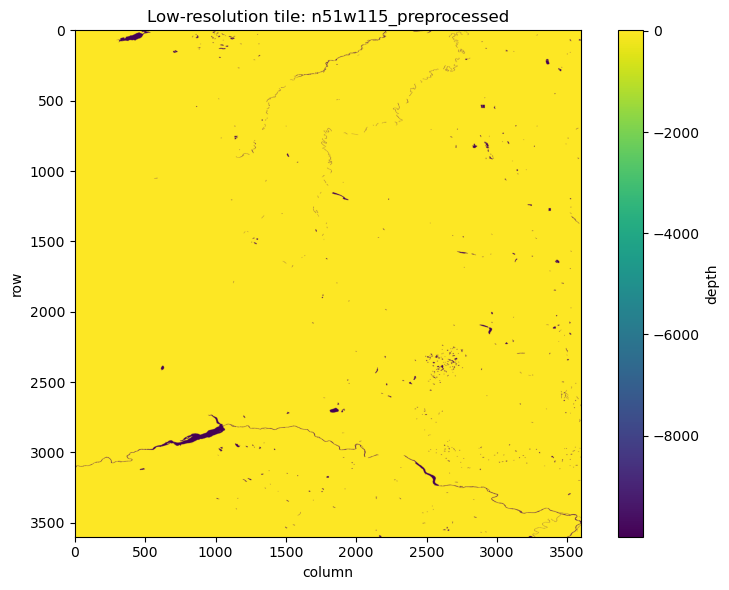

In [4]:
# Plot the low-resolution tile with a simple viridis colormap.
with rasterio.open(depth_lr_fp) as src:
    depth_lr_arr = src.read(1)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(depth_lr_arr, cmap="viridis")
ax.set_title("Low-resolution tile: n51w115_preprocessed")
ax.set_xlabel("column")
ax.set_ylabel("row")
fig.colorbar(im, ax=ax, label="depth")
plt.tight_layout()


# 2) FETCH HRDEM

In [5]:
# Fetch HRDEM for the low-resolution tile footprint.
logger = logging.getLogger("nb")
logger.handlers.clear()
logger.setLevel(logging.INFO)
handler = logging.StreamHandler()
handler.setLevel(logging.INFO)
handler.setFormatter(logging.Formatter("[%(levelname)s]%(name)s: %(message)s"))
logger.addHandler(handler)

result = main_fetch_hrdem_for_lowres_tile(
    depth_lr_fp=depth_lr_fp,
    output_fp=hrdem_fp,
    logger=logger,
)

print(f"Fetched HRDEM path:{result.dem_fp}")


[INFO]nb: starting DEM fetch
  source_id=hrdem
  stac_url=https://datacube.services.geo.ca/api
  collection=hrdem-mosaic-1m
  asset_key=dtm
  force_tiling=False
  fetch_window_size=256
  memory_limit_gib=16.00
  stac_query_limit=200
  use_project_extent_filter=True
  use_cache=True
  tqdm_disable=False
  project_extent_url=https://maps-cartes.services.geo.ca/server_serveur/rest/services/NRCan/coverage_HRDEM_en/MapServer/4
  depth_lr_fp=
    /workspace/tests/data/fathom_n51w115/n51w115_preprocessed.tif
[INFO]nb: found 2 HRDEM item(s) intersecting low-res tile bounds after exact intersection filter
[WARNING]nb: auto-enabling tiled fetch: estimated float32 raster memory 46.38 GiB exceeds limit 16.00 GiB
[INFO]nb: raw fetch request grid: width=98,888, height=125,890, pixels=12,449,010,320, float32_estimate=46.38 GiB
[INFO]nb: window tiling plan: lowres_window_shape=256 x 256, lowres_grid=15x15, tiles_total=225, full_tiles=196, edge_tiles=29
[INFO]nb: downloaded 8 HRDEM project extent featu

KeyboardInterrupt: 

# 3) PLOT HRDEM

In [ ]:
# Plot the downloaded HRDEM raster.
with rasterio.open(result.dem_fp) as src:
    hrdem_arr = src.read(1)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(hrdem_arr, cmap="terrain")
ax.set_title("Downloaded HRDEM")
ax.set_xlabel("column")
ax.set_ylabel("row")
fig.colorbar(im, ax=ax, label="elevation")
plt.tight_layout()
